# Практикум «Прогнозирование и моделирование» (Python)

**Фамилия, имя:** ______________________  **Класс:** 10 ___

Три задания — три вопроса управляющего школьным кафе:

1. **Регрессия** — как связаны реклама и выручка, цена и спрос?
2. **Временной ряд** — какой будет выручка в следующем квартале?
3. **Анализ «что если»** — какую цену назначить, что будет при росте аренды, каковы риски?

Как работать:
- выполняйте ячейки сверху вниз (**Shift + Enter**); ячейки с данными и вспомогательными функциями менять не нужно;
- свой код пишите в ячейках с пометкой `# ВАШ КОД`, заменяя `None` на формулы;
- текстовые ответы пишите в ячейках **Ответ:** (двойной щелчок по ячейке — редактирование);
- в конце проверьте: *Kernel → Restart & Run All* должно выполняться без ошибок.

Используем `numpy`, `pandas`, `matplotlib`, `scipy`. Аналоги функций Excel: `ЛИНЕЙН` → `np.polyfit` / `np.linalg.lstsq`, `ПРЕДСКАЗ`/`ТЕНДЕНЦИЯ` → подстановка в `a + b·t`, «Подбор параметра» → `goal_seek` (см. ниже), «Таблица данных» → `pandas.DataFrame`.

## 0. Подготовка: библиотеки и вспомогательные функции

Эту ячейку просто выполните.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.precision", 2)


def r_squared(y, y_hat):
    """Коэффициент детерминации R² = 1 − SS_ост / SS_общ (аналог КВПИРСОН)."""
    y, y_hat = np.asarray(y, float), np.asarray(y_hat, float)
    ss_res = ((y - y_hat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot


def goal_seek(func, target, lo, hi):
    """Аналог «Подбора параметра»: ищет x на отрезке [lo, hi], при котором func(x) == target.
    На концах отрезка func(x) − target должна иметь разные знаки (иначе решения на отрезке нет)."""
    return brentq(lambda x: func(x) - target, lo, hi)


print("Библиотеки загружены. numpy", np.__version__, "| pandas", pd.__version__)

Библиотеки загружены. numpy 2.3.5 | pandas 2.3.3


## Задание 1А. Реклама → выручка интернет-магазина

За 12 месяцев известны расходы на рекламу `x` (тыс. руб.) и выручка `y` (тыс. руб.).

Нужно:
1. построить линейную модель `y = a + b·x` методом наименьших квадратов;
2. найти R² и коэффициент корреляции r;
3. спрогнозировать выручку при рекламе 150 тыс. руб.;
4. нарисовать диаграмму рассеяния с линией регрессии;
5. объяснить смысл коэффициента `b` и ограничения прогноза.

In [ ]:
# Данные (менять не нужно)
months = ["янв", "фев", "мар", "апр", "май", "июн", "июл", "авг", "сен", "окт", "ноя", "дек"]
ads = np.array([20, 25, 30, 40, 45, 55, 60, 70, 80, 90, 100, 110], dtype=float)         # x, тыс. руб.
revenue = np.array([204, 242, 217, 318, 320, 337, 354, 401, 425, 460, 514, 545], dtype=float)  # y, тыс. руб.

shop = pd.DataFrame({"Месяц": months, "Реклама, тыс. руб. (x)": ads, "Выручка, тыс. руб. (y)": revenue})
shop

,Месяц,"Реклама, тыс. руб. (x)","Выручка, тыс. руб. (y)"
0,янв,20.0,204.0
1,фев,25.0,242.0
2,мар,30.0,217.0
3,апр,40.0,318.0
4,май,45.0,320.0
5,июн,55.0,337.0
6,июл,60.0,354.0
7,авг,70.0,401.0
8,сен,80.0,425.0
9,окт,90.0,460.0


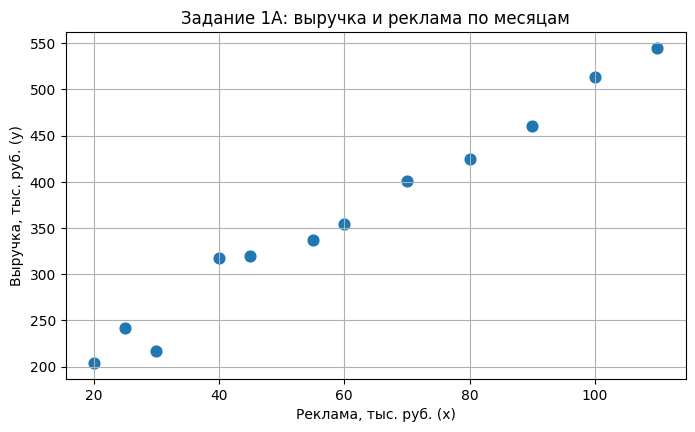

In [ ]:
# Вспомогательная ячейка: посмотрите на данные глазами, прежде чем считать
plt.scatter(ads, revenue, s=60)
plt.xlabel("Реклама, тыс. руб. (x)")
plt.ylabel("Выручка, тыс. руб. (y)")
plt.title("Задание 1А: выручка и реклама по месяцам")
plt.show()

### 1А.1 Коэффициенты модели

Подсказка: `np.polyfit(x, y, 1)` возвращает массив `[b, a]` — **сначала наклон, потом свободный член** (тот же порядок, что у `ЛИНЕЙН` в Excel). Коэффициент корреляции: `np.corrcoef(x, y)[0, 1]`.

In [ ]:
# ВАШ КОД: найдите b (наклон), a (свободный член), R² и r
b_1a = None
a_1a = None
revenue_hat = None          # предсказанные моделью значения y для каждого месяца: a + b*x
r2_1a = None                # используйте r_squared(revenue, revenue_hat)
r_1a = None                 # коэффициент корреляции

print("b =", b_1a, " a =", a_1a, " R² =", r2_1a, " r =", r_1a)

b = None  a = None  R² = None  r = None


### 1А.2 Прогноз при рекламе 150 тыс. руб.

In [ ]:
# ВАШ КОД: прогноз выручки при рекламе 150 тыс. руб. (аналог ПРЕДСКАЗ.ЛИНЕЙН)
forecast_150 = None
print("Прогноз выручки при рекламе 150:", forecast_150)

Прогноз выручки при рекламе 150: None


### 1А.3 Диаграмма рассеяния с линией регрессии

Дорисуйте к точкам прямую модели: возьмите `xx = np.linspace(0, 160, 100)` и постройте `a + b·xx`. Подпишите оси и вынесите уравнение в легенду или заголовок.

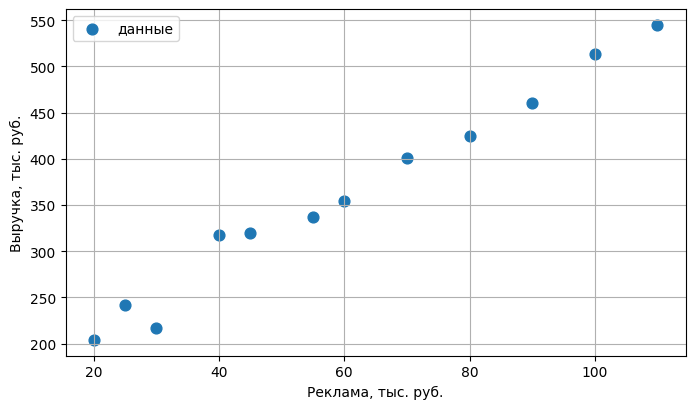

In [ ]:
# ВАШ КОД: точки + линия регрессии + подписи
plt.scatter(ads, revenue, s=60, label="данные")
# ... линия модели ...
plt.xlabel("Реклама, тыс. руб.")
plt.ylabel("Выручка, тыс. руб.")
plt.legend()
plt.show()

**Ответ (1А):**

- Смысл коэффициента b: …
- Что такое R² = … в этой задаче: …
- Почему прогнозу при рекламе 150 доверять можно меньше, чем при 60: …

## Задание 1Б. Спрос на кофе от цены и рекламы (множественная регрессия)

15 недель школьное кафе меняло цену напитка `P` (руб.) и расходы на рекламу `A` (тыс. руб.) и записывало продажи `Q` (шт.).
Модель: `Q = a + b₁·P + b₂·A`.

Нужно: найти коэффициенты и R², спрогнозировать продажи при цене 100 и рекламе 5, ответить на экономический вопрос.

In [ ]:
# Данные (менять не нужно)
price = np.array([80, 85, 90, 95, 100, 100, 105, 110, 115, 120, 125, 130, 135, 140, 140], dtype=float)   # P, руб.
adv = np.array([2, 6, 3, 8, 1, 9, 4, 7, 2, 10, 5, 3, 8, 1, 6], dtype=float)                               # A, тыс. руб.
qty = np.array([559, 654, 542, 656, 424, 678, 493, 539, 378, 610, 422, 338, 475, 257, 369], dtype=float)  # Q, шт.

cafe = pd.DataFrame({"Неделя": range(1, 16), "Цена, руб. (P)": price, "Реклама, тыс. руб. (A)": adv, "Продано, шт. (Q)": qty})
cafe.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Неделя,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
"Цена, руб. (P)",80.0,85.0,90.0,95.0,100.0,100.0,105.0,110.0,115.0,120.0,125.0,130.0,135.0,140.0,140.0
"Реклама, тыс. руб. (A)",2.0,6.0,3.0,8.0,1.0,9.0,4.0,7.0,2.0,10.0,5.0,3.0,8.0,1.0,6.0
"Продано, шт. (Q)",559.0,654.0,542.0,656.0,424.0,678.0,493.0,539.0,378.0,610.0,422.0,338.0,475.0,257.0,369.0


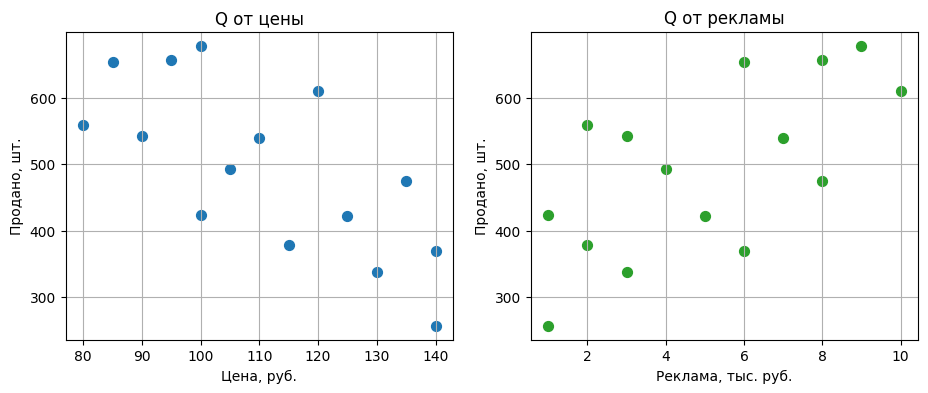

In [ ]:
# Вспомогательная ячейка: две проекции данных
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(price, qty, s=50); axes[0].set_xlabel("Цена, руб."); axes[0].set_ylabel("Продано, шт."); axes[0].set_title("Q от цены")
axes[1].scatter(adv, qty, s=50, color="C2"); axes[1].set_xlabel("Реклама, тыс. руб."); axes[1].set_ylabel("Продано, шт."); axes[1].set_title("Q от рекламы")
plt.show()

### 1Б.1 Коэффициенты множественной регрессии

Подсказка: соберите матрицу `X` из трёх столбцов — единицы (для `a`), `price`, `adv`:
`X = np.column_stack([np.ones(len(qty)), price, adv])`, затем `coef, *_ = np.linalg.lstsq(X, qty, rcond=None)` → `coef = [a, b₁, b₂]`.
(Excel-функция `ЛИНЕЙН` выдала бы тот же набор, но в обратном порядке: `b₂, b₁, a`.)

In [ ]:
# ВАШ КОД: a, b1 (при цене), b2 (при рекламе), R²
X = None
a_1b, b1_price, b2_adv = None, None, None
qty_hat = None
r2_1b = None
print("a =", a_1b, " b1 (цена) =", b1_price, " b2 (реклама) =", b2_adv, " R² =", r2_1b)

a = None  b1 (цена) = None  b2 (реклама) = None  R² = None


### 1Б.2 Прогноз и экономический вопрос

Спрогнозируйте продажи при `P = 100`, `A = 5`. Затем сравните **по выручке** два решения: (а) снизить цену на 10 руб., (б) добавить 1 тыс. руб. рекламы (её стоимость вычтите из выручки).

In [ ]:
# ВАШ КОД
def demand(P, A):
    """Спрос по модели 1Б"""
    return None

q_base = None                       # P=100, A=5
revenue_base = None                 # 100 * q_base
revenue_discount = None             # цена 90, реклама 5
revenue_more_adv = None             # цена 100, реклама 6, минус 1000 руб. затрат на рекламу
print("Прогноз Q(100, 5) =", q_base)
print("Выручка: база", revenue_base, "| скидка", revenue_discount, "| +реклама", revenue_more_adv)

Прогноз Q(100, 5) = None
Выручка: база None | скидка None | +реклама None


**Ответ (1Б):**

- При росте цены на 10 руб. спрос …
- Что выгоднее по выручке — скидка или реклама, и почему «в штуках» и «в рублях» ответы разные: …

## Задание 2А. Временной ряд: выручка магазина за 2024–2025 гг.

Известна месячная выручка (тыс. руб.) за 24 месяца. Нужно спрогнозировать январь–март 2026 г. и сумму за I квартал.

Идея: вводим **номер периода** `t = 1, 2, …, 24` и строим линейный тренд `y = a + b·t` — та же регрессия, только `x` — время. Прогноз = подстановка `t = 25, 26, 27` (так работают `ПРЕДСКАЗ.ЛИНЕЙН` и `ТЕНДЕНЦИЯ`).

In [ ]:
# Данные (менять не нужно)
sales = np.array([326, 294, 321, 306, 350, 349, 359, 335, 364, 352, 359, 380,
                  391, 387, 381, 384, 424, 417, 425, 453, 414, 470, 485, 468], dtype=float)
t = np.arange(1, len(sales) + 1)
dates = pd.period_range("2024-01", periods=len(sales), freq="M")
ts_df = pd.DataFrame({"Месяц": dates.astype(str), "t": t, "Выручка, тыс. руб.": sales})
ts_df.T

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Месяц,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,...,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
t,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
"Выручка, тыс. руб.",326.0,294.0,321.0,306.0,350.0,349.0,359.0,335.0,364.0,352.0,...,381.0,384.0,424.0,417.0,425.0,453.0,414.0,470.0,485.0,468.0


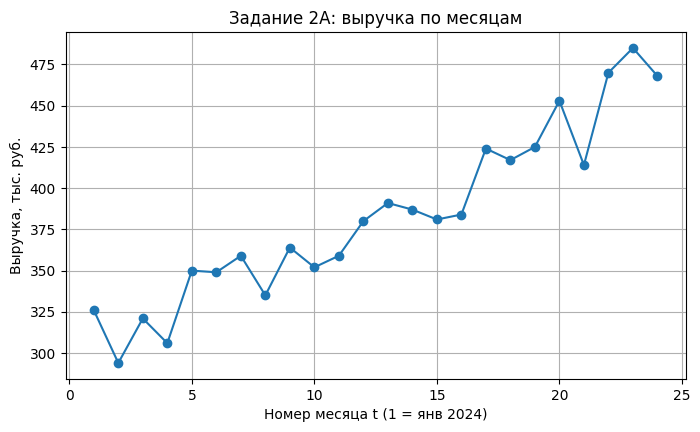

In [ ]:
# Вспомогательная ячейка: график ряда
plt.plot(t, sales, marker="o")
plt.xlabel("Номер месяца t (1 = янв 2024)")
plt.ylabel("Выручка, тыс. руб.")
plt.title("Задание 2А: выручка по месяцам")
plt.show()

### 2А.1 Линейный тренд и прогноз на I квартал 2026

In [ ]:
# ВАШ КОД: тренд y = a + b*t, R², прогноз на t = 25, 26, 27 и сумма
b_2a, a_2a = None, None
r2_2a = None
t_new = np.array([25, 26, 27])
forecast_q1 = None                      # массив из трёх прогнозов (аналог ТЕНДЕНЦИЯ)
total_q1 = None                         # сумма за квартал
forecast_dec_2026 = None                # t = 36

print("b =", b_2a, " a =", a_2a, " R² =", r2_2a)
print("Прогноз янв/фев/мар 2026:", forecast_q1, " итого:", total_q1)
print("Прогноз на декабрь 2026:", forecast_dec_2026)

b = None  a = None  R² = None
Прогноз янв/фев/мар 2026: None  итого: None
Прогноз на декабрь 2026: None


### 2А.2 График с трендом и прогнозом

Нарисуйте факт, линию тренда, продлённую до t = 27, и точки прогноза другим маркером.

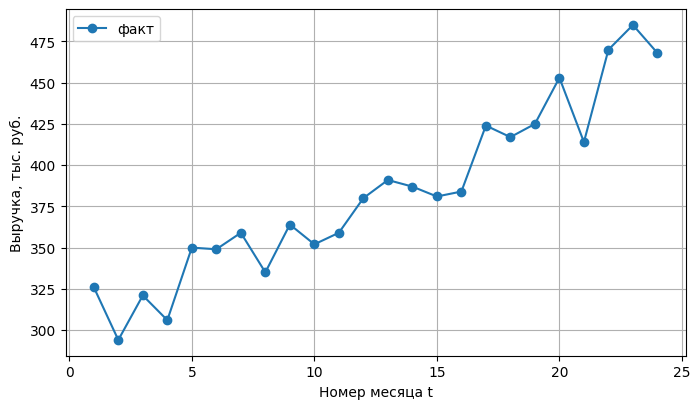

In [ ]:
# ВАШ КОД: факт + тренд + прогноз
plt.plot(t, sales, marker="o", label="факт")
# ... тренд и прогноз ...
plt.xlabel("Номер месяца t")
plt.ylabel("Выручка, тыс. руб.")
plt.legend()
plt.show()

**Ответ (2А):**

- Средний рост выручки в месяц: …
- Прогноз на I квартал 2026: …
- Почему прогнозу на t = 60 доверять нельзя, хотя формула его выдаёт: …

## Задание 2Б (*). Сезонность: квартальные продажи мороженого

12 кварталов продаж (шт.). Проверьте, годится ли линейный тренд, и постройте прогноз на 4 квартала 2026 г. с учётом сезонности.

Простой метод **сезонных индексов**:
1. индекс квартала k = (средние продажи в кварталах k) / (общее среднее);
2. ряд «без сезона» = продажи / индекс своего квартала;
3. линейный тренд по ряду без сезона;
4. прогноз = тренд(t) × индекс квартала.

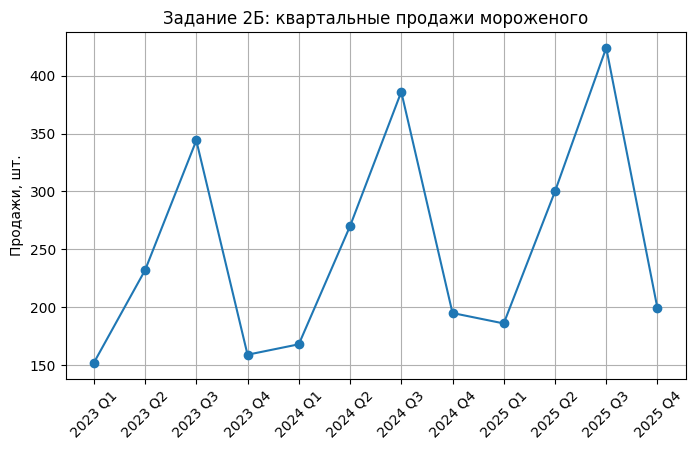

In [ ]:
# Данные (менять не нужно)
ice = np.array([152, 232, 344, 159, 168, 270, 386, 195, 186, 300, 424, 199], dtype=float)
tq = np.arange(1, 13)
quarter = (tq - 1) % 4                      # 0,1,2,3 — номер квартала внутри года
labels_q = [f"{2023 + (k - 1) // 4} Q{(k - 1) % 4 + 1}" for k in tq]

plt.plot(tq, ice, marker="o")
plt.xticks(tq, labels_q, rotation=45)
plt.ylabel("Продажи, шт.")
plt.title("Задание 2Б: квартальные продажи мороженого")
plt.show()

In [ ]:
# ВАШ КОД
b_lin, a_lin = None, None
r2_lin = None                               # R² линейного тренда по исходному ряду
season_index = None                         # массив из 4 индексов (по кварталам 0..3)
ice_deseason = None                         # ряд без сезонности
b_s, a_s = None, None                       # тренд по ряду без сезонности
t_future = np.array([13, 14, 15, 16])
forecast_linear = None                      # «наивный» линейный прогноз
forecast_season = None                      # тренд(t) * индекс квартала

print("R² линейного тренда:", r2_lin)
print("Сезонные индексы:", season_index)
print("Линейный прогноз 2026:", forecast_linear)
print("Сезонный прогноз 2026:", forecast_season)

R² линейного тренда: None
Сезонные индексы: None
Линейный прогноз 2026: None
Сезонный прогноз 2026: None


**Ответ (2Б):** почему линейный прогноз здесь бесполезен и чем сезонный лучше: …

## Задание 3. Анализ «что если»: модель прибыли школьного кафе

Спрос линейно зависит от цены: `Q = a − b·P` (коэффициенты получены регрессией, как в 1Б). Параметры базового варианта:

| Параметр | Обозначение | Значение |
|---|---|---|
| Цена напитка, руб. | P | 150 |
| Базовый спрос, шт./мес. | a | 2000 |
| Падение спроса на 1 руб. цены, шт./руб. | b | 8 |
| Переменные затраты на напиток, руб. | VC | 60 |
| Постоянные затраты (аренда, зарплата), руб./мес. | FC | 40 000 |

Прибыль = `(P − VC)·Q − FC`. Сначала оформите модель **функцией** с параметрами по умолчанию — тогда любой вопрос «что если» сводится к вызову функции с другими аргументами.

In [ ]:
# ВАШ КОД: модель
def demand_q(P, a=2000, b=8):
    """Спрос Q = a − b·P"""
    return None

def profit(P=150, a=2000, b=8, VC=60, FC=40_000):
    """Прибыль за месяц = (P − VC)·Q − FC"""
    return None

print("Базовый вариант: Q =", demand_q(150), " прибыль =", profit())   # ожидается Q = 800, прибыль = 32 000

Базовый вариант: Q = None  прибыль = None


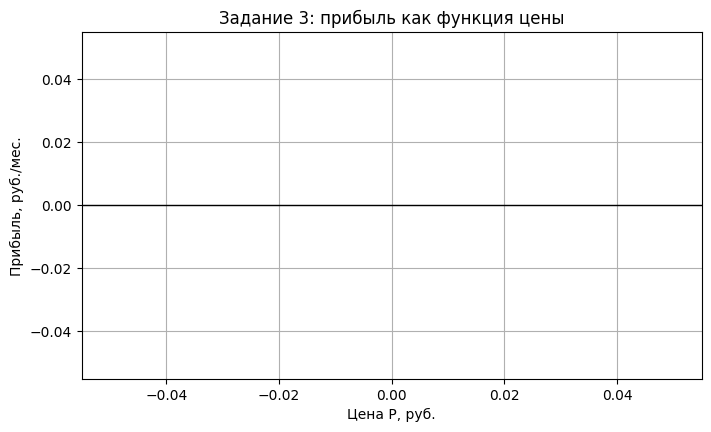

In [ ]:
# Вспомогательная ячейка: как прибыль зависит от цены (при остальных параметрах базовых)
pp = np.linspace(80, 240, 161)
plt.plot(pp, [profit(P) for P in pp], lw=2.5)
plt.axhline(0, color="black", lw=1)
plt.xlabel("Цена P, руб.")
plt.ylabel("Прибыль, руб./мес.")
plt.title("Задание 3: прибыль как функция цены")
plt.show()

### 3.1–3.3 Подбор параметра (обратная задача)

`goal_seek(func, target, lo, hi)` ищет `x` на отрезке `[lo, hi]`, при котором `func(x) == target`. Функцию одной переменной удобно задать `lambda`: например, `lambda P: profit(P)`.

- **3.1** При какой цене прибыль = 30 000? Поищите на отрезках `[100, 155]` и `[155, 250]` — сколько решений?
- **3.2** При P = 150 — какие максимальные постоянные затраты FC допустимы, чтобы прибыль была ≥ 0?
- **3.3** Цены безубыточности (прибыль = 0) при FC = 40 000 — нижняя и верхняя.

In [ ]:
# ВАШ КОД
price_for_30k_low = None
price_for_30k_high = None
max_fc = None
breakeven_low = None
breakeven_high = None

print("3.1 Цена для прибыли 30 000:", price_for_30k_low, "или", price_for_30k_high)
print("3.2 Максимальные постоянные затраты при P = 150:", max_fc)
print("3.3 Цены безубыточности:", breakeven_low, "и", breakeven_high)

3.1 Цена для прибыли 30 000: None или None
3.2 Максимальные постоянные затраты при P = 150: None
3.3 Цены безубыточности: None и None


**Ответ (3.1–3.3):** почему у задачи 3.1 два решения и какое выбрать управленцу; что означают две цены безубыточности: …

### 3.4 Таблица данных с одной переменной: чувствительность прибыли к цене

Постройте `DataFrame` для цен 100, 110, …, 220 со столбцами «Спрос», «Выручка», «Прибыль». Найдите цену с максимальной прибылью, затем уточните шагом 5 руб. (или 1 руб.) вокруг неё.

In [ ]:
# ВАШ КОД
prices = np.arange(100, 221, 10)
table_1d = None                     # pd.DataFrame(...)
best_price_rough = None             # цена с максимальной прибылью в таблице
best_price_exact = None             # уточнение шагом 1 руб. на отрезке 140..170
table_1d

### 3.5 Таблица данных с двумя переменными: цена × переменные затраты

Строки — цены 100…220 (шаг 10), столбцы — VC = 40, 50, 60, 70, 80; в ячейках — прибыль. Выделите убыточные сочетания (прибыль < 0) цветом: `table.style.map(lambda v: "color: red" if v < 0 else "")`.

In [ ]:
# ВАШ КОД
vcs = [40, 50, 60, 70, 80]
table_2d = None                     # DataFrame: index — цены, columns — VC
table_2d

### 3.6 Сценарии

Три набора параметров — соберите сводную таблицу «сценарий → спрос, выручка, прибыль» при P = 150:

| Сценарий | a | VC | FC |
|---|---|---|---|
| Пессимистичный | 1800 | 70 | 45 000 |
| Базовый | 2000 | 60 | 40 000 |
| Оптимистичный | 2200 | 55 | 40 000 |

In [ ]:
# ВАШ КОД
scenarios = {
    "Пессимистичный": dict(a=1800, VC=70, FC=45_000),
    "Базовый":        dict(a=2000, VC=60, FC=40_000),
    "Оптимистичный":  dict(a=2200, VC=55, FC=40_000),
}
scenario_table = None               # DataFrame со строками-сценариями
scenario_table

## Итог. Рекомендация управленца

Напишите 2–3 предложения **с числами из модели**: какую цену назначить, в каких границах цены бизнес прибылен, какую аренду можно себе позволить, каков риск по пессимистичному сценарию.

**Ответ:** …

---
**Перед сдачей:** *Kernel → Restart & Run All* — все ячейки должны выполниться без ошибок; у графиков подписаны оси; текстовые ответы заполнены.